<a href="https://colab.research.google.com/github/gocleanwater/AI-class/blob/main/week2/diabetesRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# diabetes의 Regression
## 왜 **회귀**인가?
- 예측하려는 값 y가 **이산적인 label**이 아닌 **연속적인 값**이기 때문이다.
- 입력값에 따라 y = df2['BMI']이고 이는 Outcome처럼 0, 1로 나눠져 있는 것이 아닌  **[23.3, 28.1, 33.6, ...etc]** 이기 때문이다.
- BMI가 얼마일지를 예측하는 모델이므로 Regression이다.

In [2]:
import pandas as pd
import numpy as np

In [3]:
path = '/content/drive/MyDrive/Colab Notebooks/AI-class/week2/diabetes.csv'

# DataFrame으로 읽기
df = pd.read_csv(path)

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
df2=df.drop('Outcome',axis=1)
# 전에 Classification에서 Outcome을 정답으로 썼고, 이번에는 BMI를 정답으로 쓰기 위해 Outcome을 뺌.
df2.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


count    768.000000
mean      31.992578
std        7.884160
min        0.000000
25%       27.300000
50%       32.000000
75%       36.600000
max       67.100000
Name: BMI, dtype: float64
Axes(0.125,0.11;0.775x0.77)


,BMI
0,33.6
1,26.6
2,23.3
3,28.1
4,43.1
...,...
763,32.9
764,36.8
765,26.2
766,30.1


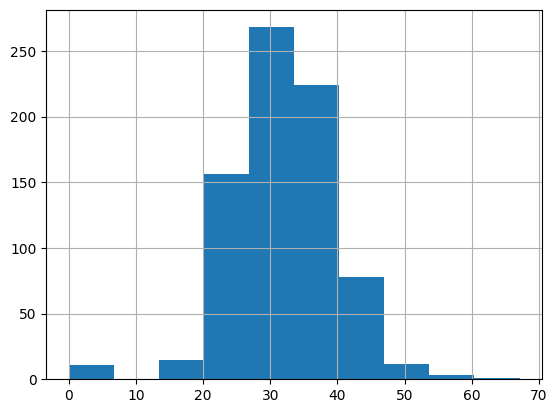

In [5]:
y=df2['BMI']

print(y.describe())
print(y.hist())

y

# y.value_counts()를 하지 않고, y.describe(), y.hist()를 하는 이유?
- Regression에서는 Classification과는 달리 연속된 값이므로 **분포**를 볼 필요가 없다.
- 회귀에서는 주로 **y.describe()나 y.hist()**를 사용한다.
---
## y.describe()와 y.hist에 대한 설명
- y.describe():
  - count : 데이터 개수
  - mean : 평균
  - std : 표준편차
  - min : 최솟값
  - 25% : 1사분위수
  - 50% : 중앙값
  - 75% : 3사분위수
  - max : 최댓값
- y.hist():
  - 어느 구간에 얼마나 몰려 있는지 그래프
---
## 근데, 그러면 왜 **평균**이나 **분포도**를 볼까??
1. 값 범위 확인
2. 평균/중앙값/퍼짐 정도 확인
3. 이상치/왜도 확: BMI는 일단 0보다 큰 실수이지만, 0일 수는 없다.(당연한 얘기)<br>이걸 통해서 데이터 중 **잘못된 데이터**가 있는지 확인할 수 있다.
4. 데이터 품질 문제 확인: 2.에서 **분포가 심하게 치우쳤는지** 확인한다. 그럼으로써 원 데이터의 y 수치가 실제 y와 얼마나 다른지 알 수 있다.<br>
무슨 소리냐면, 실제 사람들의 BMI를 측정하면 주로 20-35에 몰려 있는데, 원 데이터가 BMI가 50-65에 몰려 있다면, **원 데이터 품질이 좋지 않은 것**이다.(실험군이 BMI가 높은 쪽에 치우쳐 있었다는 소리니까)
5. MSE 해석 도움: y가 주로 20-40일 때 MSE가 10이면 큰 것이고, y가 1000-5000처럼 범위가 클 때 MSE가 10이면 작은 것이다!

In [6]:
X=df2.drop('BMI',axis=1)
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,0.627,50
1,1,85,66,29,0,0.351,31
2,8,183,64,0,0,0.672,32
3,1,89,66,23,94,0.167,21
4,0,137,40,35,168,2.288,33


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)

In [8]:
# Linear Regression 방식
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model_lr = LinearRegression()
# 선형회귀 모델 객체를 생성한다.(학습 전)
model_lr.fit(X_train, y_train)
# 학습
ly_preds = model_lr.predict(X_test)

print('평균제곱오차', mean_squared_error(y_test, ly_preds))
# mean_squared_error(y_actual(실제값), y_pred(예측값))이다. MSE를 수식으로 나타내면, MSE = (1/n)*sigma{(y_actual - y_pred)^2}이다.

# 평균제곱오차를 numpy를 이용해 직접 구한 함수이다.
def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(y_test, ly_preds))

# 평균제곱오차를 파이썬 기본 함수를 이용해 직접 구한 함수이다.
def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(y_test, ly_preds))

평균제곱오차 52.23558099742443
평균제곱오차 52.23558099742443
평균제곱오차 52.23558099742445


# 선형회귀 모델의 원리
- 선형회귀 모델을 단순하게 말하면,<br>$$y' = b_{0} + b_{1}x_{1} + b_{2}x_{2} + ... + b_{n}x_{n}$$<br>형태로 각 입력 특성에 가중치를 곱해서 BMI를 구한다.
- 수학을 아직 다 마스터하지 못해서.. 뭔 소리인지 모르겠다...
- 얘는 random_state가 없다. LinearRegression은 **결정론적**으로 계산되기 때문이다.
---
#왜 회귀는 평가로 MSE를 많이 쓸까?
- 회귀는 정답이 숫자이기 때문에, 예측이 얼마나 틀렸는지를 **거리**로 볼 수 있기 때문이다.
- 분류처럼 (맞다 / 틀리다)로 분류할 수는 없기 때문이다.
- $$오차 = 실제값 - 예측값$$
  - 왜 제곱을 할까?<br>
오차는 음수도 있기 때문에 분산처럼 제곱 후에 평균을 낸다. 또 제곱은 큰 오차에 더 큰 벌을 줄 수 있는 효과도 볼 수 있다고 한다.
---
## MSE의 수식
$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$
- $y_{i}$: Actual(실제값)
- $\hat{y}_i$: 예측값
- $n$: 데이터 개수

In [9]:
# Decision Tree Regressor 방식
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

model_lr = DecisionTreeRegressor()

model_lr.fit(X_train, y_train)
ly_preds = model_lr.predict(X_test)

print('평균제곱오차', mean_squared_error(y_test, ly_preds))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(y_test, ly_preds))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(y_test, ly_preds))

평균제곱오차 68.8721875
평균제곱오차 68.8721875
평균제곱오차 68.87218749999998


In [10]:
# Random Forest Regressor 방식
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

model_lr = RandomForestRegressor()

model_lr.fit(X_train, y_train)
ly_preds = model_lr.predict(X_test)

print('평균제곱오차', mean_squared_error(y_test, ly_preds))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(y_test, ly_preds))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(y_test, ly_preds))

평균제곱오차 45.1157804322917
평균제곱오차 45.1157804322917
평균제곱오차 45.115780432291665


Regression에 LR, DT, RF의 차이 (Linear Regression, Decision Tree Regressor, Random Forest Regressor)

https://chatgpt.com/share/69b78765-6354-800f-8667-de14d968b760